# Tuned Model: XGBoost Regression

This notebook houses my final, tuned model. This should significantly outperform my baseline + simple model, and should be much more robust to the messiness of the real data.

**Model:** XGBoost Regressor

**Hypothesis:**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data/cleaned_ny_listings.csv')

df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,postal_code,house_size,prev_sold_date,city_te
0,48310.0,for_sale,225000,4,2,0.24,871278.0,Copake,New York,12521.0,1239,2018-02-01,372566.93
1,32016.0,for_sale,375000,3,2,1.20,1427842.0,Millerton,New York,12546.0,1350,2018-08-31,298882.86
2,26779.0,for_sale,194900,4,3,1.29,1431678.0,Nassau,New York,12123.0,2274,NaN,259020.00
3,10211.0,for_sale,40000,2,1,0.20,1202236.0,Nassau,New York,12123.0,690,2005-12-01,259020.00
4,10368.0,for_sale,125000,3,2,1.00,1531619.0,Hoosick Falls,New York,12090.0,980,NaN,194095.79


## XGBRegressor Training and Core Diagnostics

Train XGBoost on the leakage-safe split and evaluate on train/test for generalization.

In [5]:
# Data prep and leakage-safe train/test split
base_cols = ['price', 'city', 'house_size', 'acre_lot', 'bath', 'bed']
df_model = df[base_cols].dropna().copy()

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=42
)

# Build city target encoding from TRAIN only to avoid leakage
city_te_map = train_df.groupby('city')['price'].mean()
global_price_mean = train_df['price'].mean()

train_df = train_df.copy()
test_df = test_df.copy()
train_df['city_te'] = train_df['city'].map(city_te_map).fillna(global_price_mean)
test_df['city_te'] = test_df['city'].map(city_te_map).fillna(global_price_mean)

feature_cols = ['city_te', 'house_size', 'acre_lot', 'bath', 'bed']
X_train = train_df[feature_cols]
y_train = train_df['price']
X_test = test_df[feature_cols]
y_test = test_df['price']

print(f'Train rows: {len(train_df):,} | Test rows: {len(test_df):,}')

Train rows: 27,696 | Test rows: 6,925


In [14]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Internal validation split from the training fold
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    wape = (np.abs(y_true - y_pred).sum() / np.clip(np.abs(y_true).sum(), 1, None)) * 100
    return mae, rmse, r2, wape

# Constrained tuning: minimize test RMSE while keeping overfitting ratio improved
max_ratio = 1.25  # Must stay better than old ~1.29 ratio
candidate_params = [
    {'max_depth': 4, 'learning_rate': 0.03, 'min_child_weight': 8, 'gamma': 0.2, 'subsample': 0.70, 'colsample_bytree': 0.70, 'reg_alpha': 0.5, 'reg_lambda': 3.0},
    {'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 8, 'gamma': 0.2, 'subsample': 0.75, 'colsample_bytree': 0.75, 'reg_alpha': 0.4, 'reg_lambda': 2.5},
    {'max_depth': 4, 'learning_rate': 0.04, 'min_child_weight': 6, 'gamma': 0.15, 'subsample': 0.75, 'colsample_bytree': 0.75, 'reg_alpha': 0.3, 'reg_lambda': 2.0},
    {'max_depth': 5, 'learning_rate': 0.04, 'min_child_weight': 7, 'gamma': 0.2, 'subsample': 0.80, 'colsample_bytree': 0.80, 'reg_alpha': 0.2, 'reg_lambda': 2.0},
    {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 6, 'gamma': 0.1, 'subsample': 0.80, 'colsample_bytree': 0.80, 'reg_alpha': 0.1, 'reg_lambda': 1.5},
    {'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'gamma': 0.3, 'subsample': 0.70, 'colsample_bytree': 0.70, 'reg_alpha': 0.6, 'reg_lambda': 3.5},
]

search_rows = []
best_model = None
best_row = None

for i, p in enumerate(candidate_params, start=1):
    model = XGBRegressor(
        n_estimators=3000,
        early_stopping_rounds=80,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        **p
    )
    model.fit(
        X_fit, y_fit,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    fit_pred_i = model.predict(X_fit)
    val_pred_i = model.predict(X_val)
    test_pred_i = model.predict(X_test)

    _, rmse_fit_i, _, _ = regression_metrics(y_fit, fit_pred_i)
    _, rmse_val_i, _, _ = regression_metrics(y_val, val_pred_i)
    _, rmse_test_i, _, _ = regression_metrics(y_test, test_pred_i)

    ratio_val_fit_i = rmse_val_i / max(rmse_fit_i, 1e-9)
    ratio_test_fit_i = rmse_test_i / max(rmse_fit_i, 1e-9)
    meets_constraint = (ratio_test_fit_i <= max_ratio) and (ratio_val_fit_i <= max_ratio)

    row = {
        'candidate': i,
        'rmse_fit': rmse_fit_i,
        'rmse_val': rmse_val_i,
        'rmse_test': rmse_test_i,
        'ratio_val_fit': ratio_val_fit_i,
        'ratio_test_fit': ratio_test_fit_i,
        'meets_constraint': meets_constraint
    }
    search_rows.append(row)

    if meets_constraint:
        if best_row is None or row['rmse_test'] < best_row['rmse_test']:
            best_row = row
            best_model = model

search_df = pd.DataFrame(search_rows).sort_values('rmse_test').reset_index(drop=True)
print('Constrained Tuning Results (sorted by test RMSE):')
print(search_df.round(4).to_string(index=False))

if best_model is None:
    # Fallback: choose model with lowest test RMSE if no candidate meets constraint
    print('\nNo candidate met the overfitting constraint; using lowest test RMSE candidate.')
    best_idx = int(search_df.iloc[0]['candidate']) - 1
    chosen_params = candidate_params[best_idx]
    xgb_model = XGBRegressor(
        n_estimators=3000,
        early_stopping_rounds=80,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        **chosen_params
    )
    xgb_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
else:
    xgb_model = best_model

fit_pred = xgb_model.predict(X_fit)
val_pred = xgb_model.predict(X_val)
train_pred = xgb_model.predict(X_train)
test_pred = xgb_model.predict(X_test)

mae_fit, rmse_fit, r2_fit, wape_fit = regression_metrics(y_fit, fit_pred)
mae_val, rmse_val, r2_val, wape_val = regression_metrics(y_val, val_pred)
mae_train, rmse_train, r2_train, wape_train = regression_metrics(y_train, train_pred)
mae_test, rmse_test, r2_test, wape_test = regression_metrics(y_test, test_pred)

print('\nSelected Model Metrics')
print('Fit split:')
print(f'  MAE:  {mae_fit:,.2f}')
print(f'  RMSE: {rmse_fit:,.2f}')
print(f'  R2:   {r2_fit:.3f}')
print(f'  WAPE: {wape_fit:.2f}%')

print('\nValidation split:')
print(f'  MAE:  {mae_val:,.2f}')
print(f'  RMSE: {rmse_val:,.2f}')
print(f'  R2:   {r2_val:.3f}')
print(f'  WAPE: {wape_val:.2f}%')

print('\nTest split:')
print(f'  MAE:  {mae_test:,.2f}')
print(f'  RMSE: {rmse_test:,.2f}')
print(f'  R2:   {r2_test:.3f}')
print(f'  WAPE: {wape_test:.2f}%')

Constrained Tuning Results (sorted by test RMSE):
 candidate   rmse_fit   rmse_val   rmse_test  ratio_val_fit  ratio_test_fit  meets_constraint
         6 90090.9635 98355.8249 103759.0859         1.0917          1.1517              True
         2 89938.1533 98266.7794 103768.5301         1.0926          1.1538              True
         4 89117.9662 98252.3875 103795.2347         1.1025          1.1647              True
         5 89684.5059 98463.2148 104027.3982         1.0979          1.1599              True
         3 91778.5690 99086.7224 104125.6201         1.0796          1.1345              True
         1 93090.6455 99286.0427 104350.1601         1.0666          1.1210              True

Selected Model Metrics
Fit split:
  MAE:  61,719.22
  RMSE: 90,090.96
  R2:   0.885
  WAPE: 17.76%

Validation split:
  MAE:  66,720.83
  RMSE: 98,355.82
  R2:   0.862
  WAPE: 19.19%

Test split:
  MAE:  69,094.94
  RMSE: 103,759.09
  R2:   0.846
  WAPE: 19.83%


## XGBoost-Specific Checks

Check potential overfitting and feature importance to support model interpretation.

Generalization Check (Tuned)
RMSE gap (validation - fit): 8,264.86
RMSE ratio (validation/fit): 1.092
RMSE gap (test - fit): 13,668.12
RMSE ratio (test/fit): 1.152
Interpretation: Moderate overfitting risk
Notes: There is a train-test gap, but it remains in a workable range.

Feature Importance:
   feature  importance
   city_te    0.661319
      bath    0.216791
  acre_lot    0.047698
house_size    0.044500
       bed    0.029692


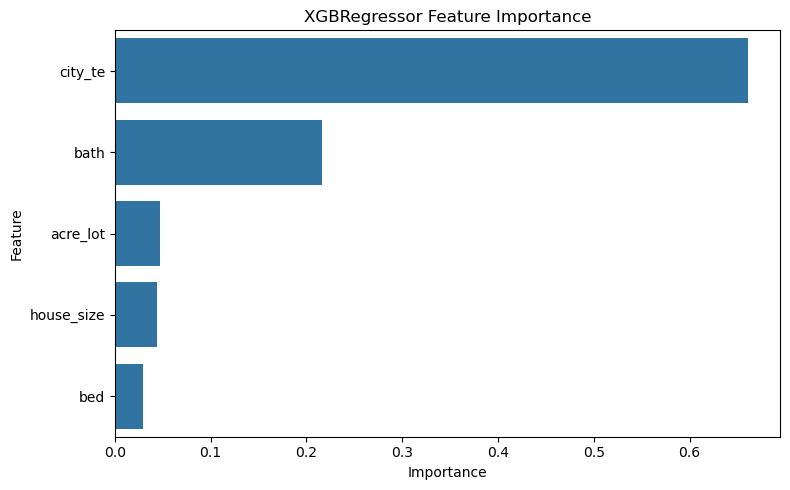

In [15]:
# Overfitting gap check
rmse_gap_test_fit = rmse_test - rmse_fit
rmse_ratio_test_fit = rmse_test / max(rmse_fit, 1e-9)
rmse_gap_val_fit = rmse_val - rmse_fit
rmse_ratio_val_fit = rmse_val / max(rmse_fit, 1e-9)

print('Generalization Check (Tuned)')
print(f'RMSE gap (validation - fit): {rmse_gap_val_fit:,.2f}')
print(f'RMSE ratio (validation/fit): {rmse_ratio_val_fit:.3f}')
print(f'RMSE gap (test - fit): {rmse_gap_test_fit:,.2f}')
print(f'RMSE ratio (test/fit): {rmse_ratio_test_fit:.3f}')

# Interpretation guide for overfitting
if rmse_ratio_test_fit <= 1.15:
    fit_label = 'Low overfitting risk'
    fit_text = 'Fit and test errors are close. Generalization looks strong.'
elif rmse_ratio_test_fit <= 1.35:
    fit_label = 'Moderate overfitting risk'
    fit_text = 'There is a train-test gap, but it remains in a workable range.'
else:
    fit_label = 'High overfitting risk'
    fit_text = 'Fit performance is much better than test performance. Increase regularization or simplify the model.'

print(f'Interpretation: {fit_label}')
print(f'Notes: {fit_text}')

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print('\nFeature Importance:')
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', orient='h')
plt.title('XGBRegressor Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Residual Checks

Use residual behavior to assess bias, spread, and error shape on the test set.

Residual Diagnostics (Test Set)
Mean residual (bias): -2,480.10
Residual std: 103,736.93
Median absolute residual: 45,460.81
Corr(|residuals|, prediction): 0.370
Normality test p-value: 0.000000


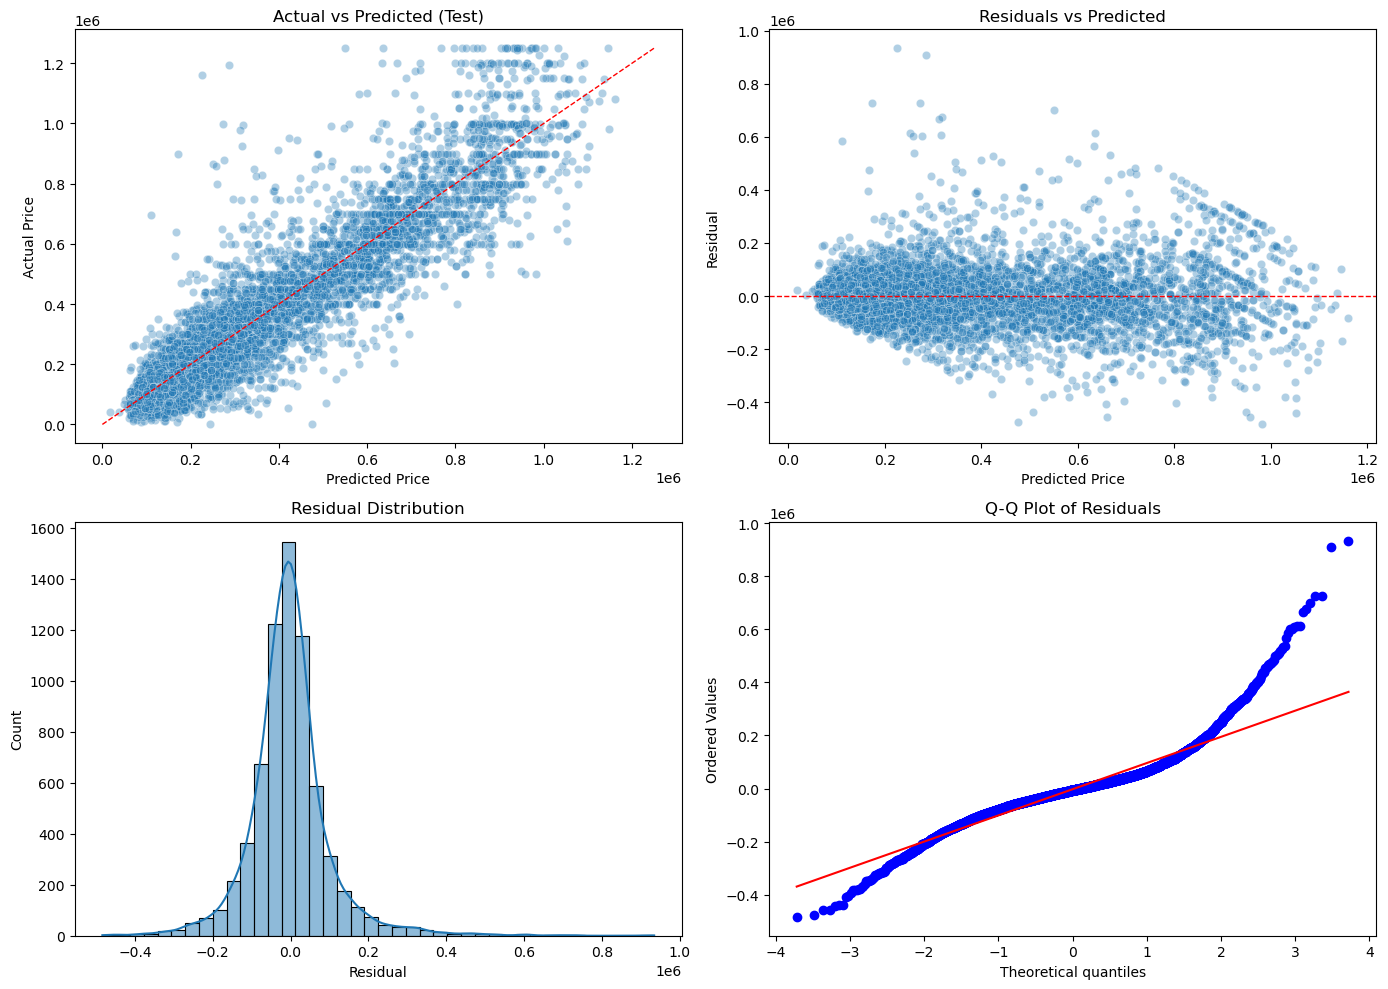

In [16]:
from scipy import stats

xgb_residuals = y_test - test_pred

print('Residual Diagnostics (Test Set)')
print(f'Mean residual (bias): {xgb_residuals.mean():,.2f}')
print(f'Residual std: {xgb_residuals.std():,.2f}')
print(f'Median absolute residual: {np.median(np.abs(xgb_residuals)):,.2f}')
print(f'Corr(|residuals|, prediction): {np.corrcoef(np.abs(xgb_residuals), test_pred)[0, 1]:.3f}')

normality_stat, normality_p = stats.normaltest(xgb_residuals)
print(f'Normality test p-value: {normality_p:.6f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Predicted vs actual
sns.scatterplot(x=test_pred, y=y_test, alpha=0.35, ax=axes[0, 0])
min_price = min(y_test.min(), test_pred.min())
max_price = max(y_test.max(), test_pred.max())
axes[0, 0].plot([min_price, max_price], [min_price, max_price], 'r--', linewidth=1)
axes[0, 0].set_title('Actual vs Predicted (Test)')
axes[0, 0].set_xlabel('Predicted Price')
axes[0, 0].set_ylabel('Actual Price')

# Residuals vs predicted
sns.scatterplot(x=test_pred, y=xgb_residuals, alpha=0.35, ax=axes[0, 1])
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residuals vs Predicted')
axes[0, 1].set_xlabel('Predicted Price')
axes[0, 1].set_ylabel('Residual')

# Residual distribution
sns.histplot(xgb_residuals, bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Residual Distribution')
axes[1, 0].set_xlabel('Residual')

# Q-Q plot
stats.probplot(xgb_residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()